In [1]:
from sklearn.linear_model import LogisticRegression

In [2]:
model = LogisticRegression()
# penalty: literal['l1','l2','elasticnet'] none='12'
# model = LogisticRegression(penalty='l1')
# model = LogisticRegression(penalty='l2')
# model = LogisticRegression(penalty='elasticnet')
''' 
solver: literal['1bfgs','liblinear','newton-cg','newton-cholesky','sag','saga'] = 'lbfgs'
'''

" \nsolver: literal['1bfgs','liblinear','newton-cg','newton-cholesky','sag','saga'] = 'lbfgs'\n"

solver                    penalty               multinomial
'lbfgs'             '12'None                     yes
'liblinear'         'l1''l2'                      no
'newton_cg          'l2'None                     yes
'newton_cholesky'   'l2'None                      no
'sag'               'l2' None                     yes
'Saga'               'elasticnet','l1','l2'None    yes

max_iter:                
max_iter: used to find the best weights    Int = 100

important int question      
4)class_weight = None | 'balanced'               
we can handle unbalanced is by using           
> class_weights         
>re-sampling            
based on value counts data can be decided as balanced or unbalanced
 
tolerance:                  
it stops iteration and reaches the best weights.                           

-------------------JULY 03------------------

In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

In [4]:
df = pd.read_csv('loan_approval_dataset.csv')
df

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No
...,...,...,...,...,...,...,...,...,...
995,22,49241,500,41020,24 months,Self-Employed,Owned,No,Yes
996,40,116214,423,12415,48 months,Self-Employed,Owned,No,Yes
997,27,64569,300,28155,36 months,Self-Employed,Rented,Yes,Yes
998,61,31745,490,48884,12 months,Self-Employed,Mortgage,No,Yes


In [5]:
X = df.drop(columns='Loan_Approved')
y = df.Loan_Approved

In [6]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

multicolinearity check

In [7]:
X.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


selecting only number and object columns

In [8]:
num_cols = X.select_dtypes(include='number').columns
obj_cols = X.select_dtypes(include='object').columns
num_cols
obj_cols

C:\Users\DELL\AppData\Local\Temp\ipykernel_76\1703309803.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X.select_dtypes(include='object').columns


Index(['Loan_Term', 'Employment_Status', 'Residence_Type', 'Previous_Default'], dtype='str')

<Axes: >

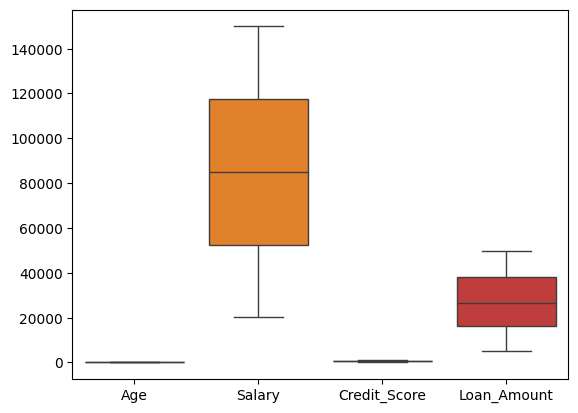

In [9]:
sns.boxplot(X[num_cols])

In [10]:
X.nunique

<bound method DataFrame.nunique of      Age  Salary  Credit_Score  Loan_Amount  Loan_Term Employment_Status  \
0     56  136748           584        38209  36 months          Employed   
1     46   25287           815        27424  24 months     Self-Employed   
2     32  146593           398        42396  12 months        Unemployed   
3     60   54387           696        11370  24 months        Unemployed   
4     25   28512           788        14528  12 months          Employed   
..   ...     ...           ...          ...        ...               ...   
995   22   49241           500        41020  24 months     Self-Employed   
996   40  116214           423        12415  48 months     Self-Employed   
997   27   64569           300        28155  36 months     Self-Employed   
998   61   31745           490        48884  12 months     Self-Employed   
999   19   46029           815        21964  24 months          Employed   

    Residence_Type Previous_Default  
0            O

Preprocessing Techniques            
    -Scaling          
    -Encoding        
why Scaling?                  
Feature(numerical) columns value are in different range(scale).so we can use scaling to equal importance for all the feature columns                       
                     
why Encoding?                     
Alogorithms can understand only numbers not strings                     

Which Scaling and Encoding techniques we can use for this ?
Scaling-       1)'MinMaxScalar'             2) 'StandardScalar'            
Encoder-       OneHotEncoder                    
Unique values are less so we can use OneHot Encoder.        

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

In [12]:
encoder = OneHotEncoder(
    sparse_output = False,
    handle_unknown = 'ignore'
)
scaling = MinMaxScaler()
model = LogisticRegression()

In [13]:
# model.fit(xtrain,ytrain)                         ValueError: could not convert string to float: '24 months'    

In [14]:
# updating xtrain

xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
# xtrain[obj_cols] = encoder.fit_transform(xtrain[obj_cols])  ValueError: Columns must be same length as key
encoded_values = encoder.fit_transform(xtrain[obj_cols])
encoded_columns = encoder.get_feature_names_out()
xtrain[encoded_columns] = encoded_values
xtrain.drop(columns=obj_cols,inplace=True)

In [15]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [16]:
# updating xtest
xtest[num_cols] = scaling.transform(xtest[num_cols])
encoded_values = encoder.transform(xtest[obj_cols])
encoded_columns = encoder.get_feature_names_out()
xtest[encoded_columns] = encoded_values
xtest.drop(columns=obj_cols,inplace=True)

In [17]:
xtest

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,0.152174,0.220886,0.521898,0.540280,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,0.434783,0.687894,0.020073,0.453711,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,0.347826,0.836468,0.760949,0.652294,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,0.434783,0.315031,0.950730,0.116550,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,0.934783,0.605720,0.693431,0.587172,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,0.347826,0.976689,0.764599,0.938296,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,0.478261,0.012071,0.034672,0.038805,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,0.086957,0.540937,0.791971,0.830012,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [18]:
model.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_pred_train = model.predict(xtrain)

In [20]:
y_pred_test = model.predict(xtest)

In [21]:
from sklearn.metrics import classification_report
print(classification_report(ytrain,y_pred_train))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



macro-average of metrics           
weighted - average of metrics along with support

In [22]:
from sklearn.metrics import classification_report
print(classification_report(ytest,y_pred_test))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.50      0.49      0.50       200



column transformer:                                                          
it is a ml technique which combines multiple preprocessing and executes parallely.                    
in column transformer we use only preprocessing techniques not algorithms.                         
syntax:                           
from sklearn.compose import columnTransformer                                                   
preprocessing = ColumnTransformer(                                               
    transformer = [                                                        
        ('name of preprocessing',preprocessing,col_names)                                                   
        (--------------------||-------------------------)                                        
    ]                                                                                          
    remainder = 'drop'/'passthrough'                    
)                                                                              

example:                                                                                          
preprocessing = ColumnTransformer(                                    
    transformer = [                                       
        ('minmax_scaling',MinMaxScalar(),                                  
        ['f1','f2']),                                       
        ('Robust_scaling',RobustScaler(),['f3','f4']),                              
        ('encoder',TargetEncoder(),['f5,'f6'])                                    
    ]                                              
)                                                      

--------------------------Decision Tree Classifier---------------------------

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

In [24]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [25]:
X = df.drop(columns='Loan_Approved')
y = df.Loan_Approved

In [26]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [27]:
model_1 = DecisionTreeClassifier()
model_2 = DecisionTreeRegressor()

In [28]:
model_1

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [29]:
model_2

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max